# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 3 — Stress intensity factor and fracture toughness

- [Exercise 3.1](#ex1) — Stress intensity factor: definitions and concepts
- [Exercise 3.2](#ex2) — Fracture assessment of a steel component
- [Exercise 3.3](#ex3) — Geometry correction for an aircraft component
- [Exercise 3.4](#ex4) — Detectability of a critical crack
- [Exercise 3.5](#ex5) — ASTM E399 fracture toughness test: SEN-3PB
- [Exercise 3.6](#ex6) — ASTM E399 fracture toughness test: CT
- [Exercise 3.7](#ex7) — Centre-cracked panel: SIF and fracture stress
- [Exercise 3.8](#ex8) — SEN-3PB: failure load prediction
- [Exercise 3.9](#ex9) — ASTM E399 validity: minimum yield stress
- [Exercise 3.10](#ex10) — Residual strength diagram
- [Exercise 3.11](#ex11) — Conceptual questions on $K$ and crack-tip behaviour


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex, Markdown, display

FS = 14
# Theme-agnostic styling: white background + explicit dark text/edges.
# This makes the figures legible both in light and dark Jupyter themes.
DARK = '#1f1f1f'
plt.rcParams.update({
    # Layout
    'figure.figsize': (10, 4.2), 'figure.dpi': 110,
    'font.family': 'serif', 'font.size': FS,
    'lines.linewidth': 2,

    # Backgrounds (explicit white, including on save)
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor':'white',
    'savefig.edgecolor':'white',

    # Foreground: text, axis labels, ticks, edges (avoid invisible-on-dark-theme)
    'text.color':         DARK,
    'axes.labelcolor':    DARK,
    'axes.edgecolor':     DARK,
    'axes.titlecolor':    DARK,
    'xtick.color':        DARK,
    'ytick.color':        DARK,
    'xtick.labelcolor':   DARK,
    'ytick.labelcolor':   DARK,
    'legend.labelcolor':  DARK,
    'legend.edgecolor':   DARK,
    'legend.facecolor':   'white',

    # Grid
    'axes.grid': True, 'grid.alpha': 0.30, 'grid.color': DARK,
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085')

# ---------- SIF shape functions ----------
def Y_feddersen(aW):
    '''Feddersen secant correction for CCT panel: Y = sqrt(sec(π a/W))'''
    return np.sqrt(1.0/np.cos(np.pi*np.asarray(aW)))

def f_SEN3PB(aW):
    '''Shape function for SEN-3PB (S=4W), ASTM E399.'''
    aw = np.asarray(aW, dtype=float)
    num = 3.0*np.sqrt(aw)
    den = 2.0*(1.0 + 2.0*aw)*(1.0 - aw)**1.5
    bracket = 1.99 - aw*(1.0 - aw)*(2.15 - 3.93*aw + 2.7*aw**2)
    return (num/den)*bracket

def f_CT(aW):
    '''Shape function for CT specimen, ASTM E399.'''
    aw = np.asarray(aW, dtype=float)
    pref = (2.0 + aw)/(1.0 - aw)**1.5
    poly = 0.886 + 4.64*aw - 13.32*aw**2 + 14.72*aw**3 - 5.6*aw**4
    return pref*poly

# K conversion:  1 MPa·sqrt(m) = sqrt(1000) N/mm^(3/2) ≈ 31.623 N·mm^-1.5
SQRT1000 = np.sqrt(1000.0)


---

## Formulary — Stress intensity factor and fracture toughness

**SIF (Mode I, general form):**
\begin{equation*}
K_I = Y\,\sigma\,\sqrt{\pi a}
\tag{F.1}\end{equation*}

**CCT panel (Feddersen secant approximation):**
\begin{equation*}
Y\!\left(\dfrac{a}{W}\right) = \sqrt{\sec\!\left(\dfrac{\pi a}{W}\right)}
\tag{F.2}\end{equation*}

**SEN-3PB ($S=4W$), ASTM E399:**
\begin{equation*}
K_I = \dfrac{P\,S}{B\,W^{3/2}}\,f(a/W)
\tag{F.3}\end{equation*}

with $f$ a polynomial in $a/W$ (see code).

**CT specimen, ASTM E399:**
\begin{equation*}
K_I = \dfrac{P}{B\,\sqrt{W}}\,f(a/W)
\tag{F.4}\end{equation*}

**Fracture condition:** $K_I = K_{IC}$, hence
\begin{equation*}
\sigma_f = \dfrac{K_{IC}}{Y\sqrt{\pi a}},\qquad
a_c = \dfrac{1}{\pi}\!\left(\dfrac{K_{IC}}{Y\,\sigma}\right)^{\!2}.
\tag{F.5}\end{equation*}

**ASTM E399 plane-strain validity:**
\begin{equation*}
B,\;(W-a)\;\ge\;2.5\,(K_Q/\sigma_e)^{\,2}
\tag{F.6}\end{equation*}

**Unit conversion:** $1\;\text{MPa}\sqrt{\text{m}} = \sqrt{1000}\,\text{N}\cdot\text{mm}^{-3/2}\approx 31.62\,\text{N}\cdot\text{mm}^{-3/2}$.


<a id='ex1'></a>
---

## Exercise 3.1 — Stress intensity factor: definitions and concepts

The stress intensity factor $K$ is defined by the equation

$$K = \beta\,S\,\sqrt{\pi\,a}.$$

(a)  Explain the meaning of each symbol in the equation: $\beta$, $S$,
    $a$.

(b)  What is the unit of $K$ in the International System of Units (SI)?
    What unit is commonly used in UK/US practice? Provide the conversion
    factor between the two.

(c)  How would you define the stress intensity factor in words? What does
    it quantify physically?

(d)  Which basic assumptions underlie the definition of $K$ (material
    behaviour, crack geometry, loading)?

(e)  $K$ and $K_t$ are fundamentally different concepts. Explain why.
    However, the parameters $\beta$ (in the $K$ definition) and $K_t$
    serve a similar purpose. Which purpose is that?

### Solution

**(a) Meaning of the symbols.**

* $\beta$ — dimensionless **geometry correction factor**, depending on the
  geometry of the cracked body and the crack length normalised by a
  characteristic dimension (e.g. $a/W$).
* $S$ — **remote (nominal) stress** applied to the body.
* $a$ — **crack length**; for a central crack of total length $2a$, $a$ is the
  half-length; for an edge crack of length $a$, $a$ is the full length.

**(b) Units.**

* SI: $K$ has units of $\text{Pa}\sqrt{\text{m}}$; practical use $\text{MPa}\sqrt{\text{m}}$.
* UK/US: $\text{ksi}\sqrt{\text{in}}$. Conversion:
  $1\,\text{ksi}\sqrt{\text{in}}\approx 1.099\,\text{MPa}\sqrt{\text{m}}$ (a 10 % difference).

**(c) Physical meaning.**

$K$ quantifies the **intensity of the singular elastic stress field** at the
crack tip. It is the amplitude of the $1/\sqrt{r}$ term in the asymptotic
expansion $\sigma_{ij}(r,\theta)=K/\sqrt{2\pi r}\,f_{ij}(\theta)$ (Schijve §5.3).
Two cracks with the same $K$ have geometrically similar stress fields at the
tip.

**(d) Assumptions.**

* Material is **linear elastic, isotropic, homogeneous** (LEFM).
* Crack tip has zero radius ($\rho\to 0$).
* **Small-scale yielding**: the plastic zone is much smaller than $a$, $(W-a)$, $B$.
* Loading is uniform remote tension (Mode I); modes II/III require their own
  $K$'s.

**(e) $K$ vs. $K_t$, and $\beta$ vs. $K_t$.**

| | $K_t$ | $K$ |
|---|---|---|
| Domain | finite-radius notch | sharp crack ($\rho\to 0$) |
| Dimensionality | dimensionless | $\text{MPa}\sqrt{\text{m}}$ |
| Contains load? | no — geometry only | yes — geometry **and** load |

$\beta$ in $K=\beta S\sqrt{\pi a}$ plays the **same role** as $K_t$: it is
the dimensionless geometric amplification factor, isolating the geometry from
the loading.


<a id='ex2'></a>
---

## Exercise 3.2 — Fracture assessment of a steel component

A specimen of AISI 4340 steel has a plane-strain fracture toughness
$K_{IC} = 54.8\;\text{MPa}\sqrt{\text{m}}$ and is subjected to a remote
tensile stress of $\sigma = 1030$ MPa. The specimen contains an edge
crack of length $a = 0.50$ mm. Assume a geometry correction factor
$Y = 1$ (semi-infinite plate).

(a)  Compute the applied stress intensity factor $K_I$.

(b)  Determine the fracture stress $\sigma_f$ for this crack size.

(c)  Will the specimen fracture under the applied stress? Justify by
    comparing $K_I$ with $K_{IC}$, or equivalently, $\sigma$ with
    $\sigma_f$.

(d)  Compute the critical crack size $a_c$ for the applied stress
    $\sigma = 1030$ MPa. Interpret the result: if $a < a_c$, no fracture
    occurs.

### Solution

#### (a) Applied SIF

\begin{equation*}
K_I = Y\sigma\sqrt{\pi a} = 1\cdot 1030\cdot\sqrt{\pi\cdot 0.5\times 10^{-3}}
    \approx 40.8~\text{MPa}\sqrt{\text{m}}.
\tag{3.2.1}\end{equation*}


In [57]:
K_IC, sigma, a, Y = 54.8, 1030.0, 0.5e-3, 1.0     # MPa*sqrt(m), MPa, m, -
sqrt_pia = np.sqrt(np.pi*a)
K_I = Y*sigma*sqrt_pia
print(f'(a) a = {a*1e3:.3f} mm = {a:.4e} m')
print(f'    sqrt(pi*a) = sqrt(pi x {a:.4e}) = {sqrt_pia:.5f} m^(1/2)')
print(f'    K_I = Y x sigma x sqrt(pi*a)')
print(f'        = {Y} x {sigma:.1f} x {sqrt_pia:.5f}')
print(f'        = {K_I:.2f} MPa*sqrt(m)   (K_IC = {K_IC} MPa*sqrt(m))')


(a) a = 0.500 mm = 5.0000e-04 m
    sqrt(pi*a) = sqrt(pi x 5.0000e-04) = 0.03963 m^(1/2)
    K_I = Y x sigma x sqrt(pi*a)
        = 1.0 x 1030.0 x 0.03963
        = 40.82 MPa*sqrt(m)   (K_IC = 54.8 MPa*sqrt(m))


#### (b) Fracture stress for $a=0.5$ mm

\begin{equation*}
\sigma_f = \dfrac{K_{IC}}{Y\sqrt{\pi a}}
        = \dfrac{54.8}{1\cdot\sqrt{\pi\cdot 5\times 10^{-4}}}
        \approx 1382~\text{MPa}.
\tag{3.2.2}\end{equation*}


In [58]:
sqrt_pia = np.sqrt(np.pi*a)
sigma_f = K_IC / (Y*sqrt_pia)
print(f'(b) sqrt(pi*a) = sqrt(pi x {a:.4e} m) = {sqrt_pia:.5f} m^(1/2)')
print(f'    Y*sqrt(pi*a) = {Y} x {sqrt_pia:.5f} = {Y*sqrt_pia:.5f} m^(1/2)')
print(f'    sigma_f = K_IC / (Y*sqrt(pi*a)) = {K_IC} / {Y*sqrt_pia:.5f}')
print(f'           = {sigma_f:.1f} MPa')


(b) sqrt(pi*a) = sqrt(pi x 5.0000e-04 m) = 0.03963 m^(1/2)
    Y*sqrt(pi*a) = 1.0 x 0.03963 = 0.03963 m^(1/2)
    sigma_f = K_IC / (Y*sqrt(pi*a)) = 54.8 / 0.03963
           = 1382.7 MPa


#### (c) Will the specimen fracture?

$K_I=40.8\,\text{MPa}\sqrt{\text{m}}<K_{IC}=54.8\,\text{MPa}\sqrt{\text{m}}$ →
**No fracture**. Equivalently $\sigma=1030<\sigma_f=1382$ MPa.


In [59]:
verdict = 'NO fracture' if K_I < K_IC else 'FRACTURE'
print(f'(c) K_I/K_IC = {K_I/K_IC:.3f}  →  {verdict}')


(c) K_I/K_IC = 0.745  →  NO fracture


#### (d) Critical crack size at $\sigma=1030$ MPa

\begin{equation*}
a_c = \dfrac{1}{\pi}\!\left(\dfrac{K_{IC}}{Y\sigma}\right)^{\!2}
    = \dfrac{1}{\pi}\!\left(\dfrac{54.8}{1030}\right)^{\!2}
    \approx 9.0\times 10^{-4}\;\text{m}\approx 0.90~\text{mm}.
\tag{3.2.3}\end{equation*}

Since $a=0.50<a_c=0.90$ mm, no fracture at the applied stress — consistent
with (c).


In [60]:
ratio_KS = K_IC / (Y*sigma)
a_c = (1.0/np.pi)*ratio_KS**2
print(f'(d) K_IC/(Y*sigma) = {K_IC} / ({Y} x {sigma:.1f}) = {ratio_KS:.6f} m^(1/2)')
print(f'    [K_IC/(Y*sigma)]^2 = ({ratio_KS:.6f})^2 = {ratio_KS**2:.6e} m')
print(f'    a_c = (1/pi) x [K_IC/(Y*sigma)]^2')
print(f'        = {ratio_KS**2:.6e} / {np.pi:.5f}')
print(f'        = {a_c*1e3:.3f} mm')
print(f'    a = {a*1e3:.3f} mm  <  a_c = {a_c*1e3:.3f} mm  ->  safe')


(d) K_IC/(Y*sigma) = 54.8 / (1.0 x 1030.0) = 0.053204 m^(1/2)
    [K_IC/(Y*sigma)]^2 = (0.053204)^2 = 2.830653e-03 m
    a_c = (1/pi) x [K_IC/(Y*sigma)]^2
        = 2.830653e-03 / 3.14159
        = 0.901 mm
    a = 0.500 mm  <  a_c = 0.901 mm  ->  safe


<a id='ex3'></a>
---

## Exercise 3.3 — Geometry correction factor for an aircraft component

An aircraft component is fabricated from a high-strength aluminium alloy
with a plane-strain fracture toughness
$K_{IC} = 35\;\text{MPa}\sqrt{\text{m}}$. The component was designed so
that, in the presence of an internal crack of total length
$2a = 2.00$ mm, fracture only occurs for a tensile stress of 250 MPa.

(a)  Determine the geometry correction factor $Y$ used in the design
    (recall that $a$ in Eq. (eq:K) is the half-crack length for a
    central crack).

(b)  A subsequent inspection reveals an internal crack of total length
    $2a = 1.00$ mm. Using the $Y$ factor computed in (a), determine
    whether fracture will occur if a stress of 325 MPa is applied.

(c)  Discuss the physical meaning of $Y > 1$: what kind of geometric or
    loading configuration might lead to such an amplification of the
    stress intensity factor?

### Solution

#### (a) Determine $Y$

At fracture, $K_I=K_{IC}$:

\begin{equation*}
Y = \dfrac{K_{IC}}{\sigma\sqrt{\pi a}}
   = \dfrac{35}{250\cdot\sqrt{\pi\cdot 1\times 10^{-3}}}
   \approx 2.50.
\tag{3.3.1}\end{equation*}


In [61]:
K_IC, sigma_fr, a = 35.0, 250.0, 1.0e-3            # MPa*sqrt(m), MPa, m
sqrt_pia = np.sqrt(np.pi*a)
Y = K_IC / (sigma_fr*sqrt_pia)
print(f'(a) a = {a*1e3:.1f} mm = {a:.4e} m')
print(f'    sqrt(pi*a) = sqrt(pi x {a:.4e}) = {sqrt_pia:.5f} m^(1/2)')
print(f'    sigma*sqrt(pi*a) = {sigma_fr} x {sqrt_pia:.5f} = {sigma_fr*sqrt_pia:.5f}')
print(f'    Y = K_IC / (sigma*sqrt(pi*a)) = {K_IC} / {sigma_fr*sqrt_pia:.5f}')
print(f'      = {Y:.3f}')


(a) a = 1.0 mm = 1.0000e-03 m
    sqrt(pi*a) = sqrt(pi x 1.0000e-03) = 0.05605 m^(1/2)
    sigma*sqrt(pi*a) = 250.0 x 0.05605 = 14.01248
    Y = K_IC / (sigma*sqrt(pi*a)) = 35.0 / 14.01248
      = 2.498


#### (b) New inspection: $2a=1.00$ mm at $\sigma=325$ MPa — fracture?

\begin{equation*}
K_I = Y\sigma\sqrt{\pi a}
    = 2.50\cdot 325\cdot\sqrt{\pi\cdot 5\times 10^{-4}}
    \approx 32.2~\text{MPa}\sqrt{\text{m}}\;\;<\;K_{IC}.
\tag{3.3.2}\end{equation*}

**No fracture** (just barely safe, ~8 % margin).


In [62]:
a_new, sigma_new = 0.5e-3, 325.0                    # m, MPa
sqrt_pia_new = np.sqrt(np.pi*a_new)
K_I_new = Y*sigma_new*sqrt_pia_new
print(f'(b) a_new = {a_new*1e3:.1f} mm = {a_new:.4e} m')
print(f'    sqrt(pi*a_new) = sqrt(pi x {a_new:.4e}) = {sqrt_pia_new:.5f} m^(1/2)')
print(f'    K_I = Y x sigma x sqrt(pi*a_new)')
print(f'        = {Y:.3f} x {sigma_new} x {sqrt_pia_new:.5f}')
print(f'        = {K_I_new:.2f} MPa*sqrt(m)   vs K_IC = {K_IC} MPa*sqrt(m)')
print(f'    K_I/K_IC = {K_I_new/K_IC:.3f}  ->  {"NO fracture" if K_I_new < K_IC else "FRACTURE"}')


(b) a_new = 0.5 mm = 5.0000e-04 m
    sqrt(pi*a_new) = sqrt(pi x 5.0000e-04) = 0.03963 m^(1/2)
    K_I = Y x sigma x sqrt(pi*a_new)
        = 2.498 x 325.0 x 0.03963
        = 32.17 MPa*sqrt(m)   vs K_IC = 35.0 MPa*sqrt(m)
    K_I/K_IC = 0.919  ->  NO fracture


#### (c) Why $Y>1$?

Geometric features that **amplify** the SIF beyond the infinite-plate limit:
* finite width (boundary effects),
* a notch or stress concentrator adjacent to the crack,
* bending superposed on tension,
* a crack lying in a non-uniform stress field (e.g. residual stresses).

In this exercise $Y=2.5$ is large — consistent with a crack near a stress-
raising feature (rivet hole, fillet) on an aircraft skin.


<a id='ex4'></a>
---

## Exercise 3.4 — Detectability of a critical crack

A wide structural component (plate with large dimensions) is to be
fabricated from a high-strength steel with
$K_{IC} = 77\;\text{MPa}\sqrt{\text{m}}$ and $\sigma_e = 1400$ MPa. The
minimum resolution of the available non-destructive inspection (NDI)
equipment is 4 mm (i.e. any defect with total length $\geq 4$ mm can be
detected). The design stress is $\sigma = \sigma_e / 2 = 700$ MPa.
Assume $Y = 1$ and consider a central crack ($2a$).

(a)  Calculate the critical half-crack length $a_c$ under the design
    stress.

(b)  Determine whether the critical crack ($2a_c$) would be detectable by
    the NDI equipment.

(c)  If instead the crack were an edge crack (length $a$, still with
    $Y = 1$), would the critical crack still be detectable? Discuss the
    design implications if the answer is negative.

(d)  What is the maximum design stress that ensures the critical *edge*
    crack is detectable (i.e. $a_c \geq 4$ mm)?

### Solution

#### (a) Critical half-crack for a central crack

\begin{equation*}
a_c = \dfrac{1}{\pi}\!\left(\dfrac{K_{IC}}{Y\sigma}\right)^{\!2}
    = \dfrac{1}{\pi}\!\left(\dfrac{77}{700}\right)^{\!2}
    \approx 3.85\times 10^{-3}~\text{m} = 3.85~\text{mm}.
\tag{3.4.1}\end{equation*}


In [63]:
K_IC, sigma_e, sigma, NDI, Y = 77.0, 1400.0, 700.0, 4.0e-3, 1.0
ratio_KS = K_IC / (Y*sigma)
a_c = (1.0/np.pi)*ratio_KS**2
print(f'(a) K_IC/(Y*sigma) = {K_IC} / ({Y} x {sigma:.0f}) = {ratio_KS:.6f} m^(1/2)')
print(f'    [K_IC/(Y*sigma)]^2 = {ratio_KS**2:.6e} m')
print(f'    a_c = (1/pi) x {ratio_KS**2:.6e} = {a_c*1e3:.3f} mm')
print(f'    2*a_c = {2*a_c*1e3:.2f} mm')


(a) K_IC/(Y*sigma) = 77.0 / (1.0 x 700) = 0.110000 m^(1/2)
    [K_IC/(Y*sigma)]^2 = 1.210000e-02 m
    a_c = (1/pi) x 1.210000e-02 = 3.852 mm
    2*a_c = 7.70 mm


#### (b) Is $2a_c$ detectable?

Total critical crack $2a_c = 7.71$ mm $> 4$ mm → **detectable**. ✓

#### (c) Edge crack with $Y=1$: is $a_c$ detectable?

Now $a_c$ itself is the full crack length. $a_c=3.85$ mm $< 4$ mm → **NOT
detectable**. Catastrophic failure could occur before the crack is found.

#### (d) Maximum design stress for $a_c\ge 4$ mm (edge crack)

\begin{equation*}
\sigma_{\max} = \dfrac{K_{IC}}{Y\sqrt{\pi a_{\text{NDI}}}}
              = \dfrac{77}{\sqrt{\pi\cdot 4\times 10^{-3}}}
              \approx 687~\text{MPa}.
\tag{3.4.2}\end{equation*}


In [64]:
det_central = (2*a_c) >= NDI
det_edge    = a_c       >= NDI
print(f'(b) Central crack: 2*a_c = {2*a_c*1e3:.2f} mm  vs NDI = {NDI*1e3:.0f} mm  -> '
      f'{"DETECTABLE" if det_central else "NOT detectable"}')
print(f'(c) Edge crack:    a_c   = {a_c*1e3:.2f} mm  vs NDI = {NDI*1e3:.0f} mm  -> '
      f'{"DETECTABLE" if det_edge else "NOT detectable"}')

sqrt_piNDI = np.sqrt(np.pi*NDI)
sigma_max_safe = K_IC / (Y*sqrt_piNDI)
print(f'(d) sigma_max = K_IC / (Y*sqrt(pi*a_NDI))')
print(f'    sqrt(pi x {NDI*1e3:.0f}mm) = sqrt(pi x {NDI:.4f} m) = {sqrt_piNDI:.5f} m^(1/2)')
print(f'    sigma_max = {K_IC} / ({Y} x {sqrt_piNDI:.5f}) = {sigma_max_safe:.1f} MPa')
print(f'              = {sigma_max_safe/sigma_e*100:.1f}% of sigma_e')


(b) Central crack: 2*a_c = 7.70 mm  vs NDI = 4 mm  -> DETECTABLE
(c) Edge crack:    a_c   = 3.85 mm  vs NDI = 4 mm  -> NOT detectable
(d) sigma_max = K_IC / (Y*sqrt(pi*a_NDI))
    sqrt(pi x 4mm) = sqrt(pi x 0.0040 m) = 0.11210 m^(1/2)
    sigma_max = 77.0 / (1.0 x 0.11210) = 686.9 MPa
              = 49.1% of sigma_e


<a id='ex5'></a>
---

## Exercise 3.5 — ASTM E399 fracture toughness test: SEN-3PB

A fracture test was conducted on a single-edge-notched three-point
bending (SEN-3PB) specimen made from a high-strength low-alloy steel,
following the ASTM E399 standard. The specimen has the following
dimensions and properties:

|                                      |                       |
|:-------------------------------------|:----------------------|
| Thickness                            | $B = 25$ mm           |
| Width (height)                       | $W = 50$ mm           |
| Support span                         | $S = 4W = 200$ mm     |
| Crack length (from fracture surface) | $a = 23.75$ mm        |
| Yield stress ($0.2\%$)               | $\sigma_e = 1640$ MPa |

The load–displacement record
(Figure (fig:SEN3PB)) is of ASTM E399 Type III
(linear to failure), with $P_Q = P_{\max} = 27.2$ kN. Therefore,
$P_{\max}/P_Q = 1.00 < 1.10$, satisfying the first validity criterion.

(a)  Compute the ratio $a/W$ and evaluate the shape function $f(a/W)$
    using Eq. (eq:SEN3PB).

(b)  Calculate the provisional fracture toughness $K_Q$.

(c).  Convert $K_Q$ from $\text{N}\cdot\text{mm}^{-3/2}$ to
    $\text{MPa}\sqrt{\text{m}}$. State the conversion factor.

(d)  Apply the ASTM E399 ligament validity check
    (Eq. (eq:E399)): compute
    $2.5\,(K_Q/\sigma_e)^2$ and compare with $(W - a)$. Is $K_Q$ a valid
    $K_{IC}$ value?

(e)  If the validity check in (d) had failed, what practical modification
    to the specimen would you recommend to obtain a valid $K_{IC}$?

### Solution


#### (a) $a/W$ and $f(a/W)$


In [65]:
B, W, S = 25.0, 50.0, 200.0      # mm
a = 23.75                         # mm
sigma_e = 1640.0                  # MPa
P_Q = 27.2e3                      # N
aW = a/W
fval = f_SEN3PB(aW)
print(f'(a) a/W = {a}/{W} = {aW:.4f}')
print(f'    f(a/W) = {fval:.4f}  [SEN-3PB polynomial]')


(a) a/W = 23.75/50.0 = 0.4750
    f(a/W) = 2.4633  [SEN-3PB polynomial]


#### (b) Provisional fracture toughness $K_Q$ in N·mm⁻³ᐟ²

\begin{equation*}
K_Q = \dfrac{P_Q\,S}{B\,W^{3/2}}\,f(a/W).
\tag{3.5.1}\end{equation*}


In [66]:
PQ_S   = P_Q * S                        # N*mm
B_W32  = B * W**1.5                     # mm^(5/2)
K_Q_Nmm = PQ_S / B_W32 * fval
print(f'(b) P_Q x S = {P_Q:.0f} x {S:.0f} = {PQ_S:.0f} N*mm')
print(f'    B x W^(3/2) = {B} x {W:.0f}^1.5 = {B} x {W**1.5:.2f} = {B_W32:.2f} mm^(5/2)')
print(f'    P_Q*S / (B*W^3/2) = {PQ_S:.0f} / {B_W32:.2f} = {PQ_S/B_W32:.4f} N*mm^(-3/2)')
print(f'    K_Q = {PQ_S/B_W32:.4f} x f(a/W) = {PQ_S/B_W32:.4f} x {fval:.4f}')
print(f'        = {K_Q_Nmm:.1f} N*mm^(-3/2)')


(b) P_Q x S = 27200 x 200 = 5440000 N*mm
    B x W^(3/2) = 25.0 x 50^1.5 = 25.0 x 353.55 = 8838.83 mm^(5/2)
    P_Q*S / (B*W^3/2) = 5440000 / 8838.83 = 615.4657 N*mm^(-3/2)
    K_Q = 615.4657 x f(a/W) = 615.4657 x 2.4633
        = 1516.1 N*mm^(-3/2)


#### (c) Convert to MPa·√m

Conversion factor: $1$ MPa·√m $=\sqrt{1000}$ N·mm⁻³ᐟ² $\approx 31.623$.


In [67]:
K_Q_MPa_sqrt_m = K_Q_Nmm / SQRT1000
print(f'(c) Conversion: 1 MPa√m = √1000 ≈ {SQRT1000:.3f} N·mm^(-3/2)')
print(f'    K_Q = {K_Q_Nmm:.1f} / {SQRT1000:.3f} = {K_Q_MPa_sqrt_m:.2f} MPa√m')


(c) Conversion: 1 MPa√m = √1000 ≈ 31.623 N·mm^(-3/2)
    K_Q = 1516.1 / 31.623 = 47.94 MPa√m


#### (d) ASTM E399 ligament validity check

\begin{equation*}
2.5\,(K_Q/\sigma_e)^{\,2} = 2.5\,(K_Q[\text{MPa}\sqrt{\text{m}}]/\sigma_e[\text{MPa}])^{\,2}~\text{m}.
\tag{3.5.2}\end{equation*}

Compare with $B$ and $(W-a)$ — both in mm, so we convert the right-hand
side to mm by $\times 10^{3}$.


In [68]:
ligament   = W - a
ratio_KQ   = K_Q_MPa_sqrt_m / sigma_e
min_req_mm = 2.5 * ratio_KQ**2 * 1e3
print(f'(d) K_Q/sigma_e = {K_Q_MPa_sqrt_m:.2f} / {sigma_e:.0f} = {ratio_KQ:.5f} m^(1/2)')
print(f'    (K_Q/sigma_e)^2 = ({ratio_KQ:.5f})^2 = {ratio_KQ**2:.6e} m')
print(f'    2.5 x (K_Q/sigma_e)^2 = 2.5 x {ratio_KQ**2:.6e} = {min_req_mm:.2f} mm')
print(f'    Thickness B    = {B} mm     {">=  ok" if B>=min_req_mm else "<   FAIL"}')
print(f'    Ligament W-a   = {ligament} mm  {">=  ok" if ligament>=min_req_mm else "<   FAIL"}')
valid = (B >= min_req_mm) and (ligament >= min_req_mm)
print(f'    K_Q = {K_Q_MPa_sqrt_m:.2f} MPa*sqrt(m) is {"VALID" if valid else "NOT VALID"} as K_IC')


(d) K_Q/sigma_e = 47.94 / 1640 = 0.02923 m^(1/2)
    (K_Q/sigma_e)^2 = (0.02923)^2 = 8.545600e-04 m
    2.5 x (K_Q/sigma_e)^2 = 2.5 x 8.545600e-04 = 2.14 mm
    Thickness B    = 25.0 mm     >=  ok
    Ligament W-a   = 26.25 mm  >=  ok
    K_Q = 47.94 MPa*sqrt(m) is VALID as K_IC


#### (e) If the check fails

Increase $B$ and/or $W$ until both dimensions exceed $2.5(K_Q/\sigma_e)^{2}$.
For very tough materials at modest yield strength, a valid plane-strain
$K_{IC}$ may require unreasonably large specimens — that is when fracture
toughness must be characterised by **$J$-integral** or **CTOD** instead.


<a id='ex6'></a>
---

## Exercise 3.6 — ASTM E399 fracture toughness test: CT specimen

A fracture test was conducted on a compact tension (CT) specimen of
forged steel, following the ASTM E399 standard. The specimen has the
following dimensions and properties:

|              |                       |
|:-------------|:----------------------|
| Thickness    | $B = 50$ mm           |
| Width        | $W = 100$ mm          |
| Crack length | $a = 52$ mm           |
| Yield stress | $\sigma_e = 1050$ MPa |

The load–displacement record is of ASTM E399 Type I, with $P_Q = 241$ kN
and $P_{\max} = 261$ kN.

1.  Verify the first validity criterion: is $P_{\max}/P_Q \leq 1.10$?

2.  Compute $a/W$ and evaluate the shape function $f(a/W)$ using
    Eq. (eq:CT).

3.  Calculate the provisional fracture toughness $K_Q$ (in
    MPa$\sqrt{\text{m}}$).

4.  Apply the ASTM E399 ligament validity check. Is the $K_Q$ value
    valid as $K_{IC}$?

5.  If the test is not valid, compute the maximum $K_Q$ value that would
    pass the validity check with the present specimen dimensions.
    Comment on what this implies about the material’s ductility.

### Solution


#### (a) First criterion: $P_{\max}/P_Q \le 1.10$?


In [69]:
B, W = 50.0, 100.0
a = 52.0
sigma_e = 1050.0
P_Q, P_max = 241e3, 261e3
ratio = P_max/P_Q
print(f'(a) P_max/P_Q = {P_max/1e3}/{P_Q/1e3} = {ratio:.3f}  '
      f'{"≤ 1.10  ✓" if ratio<=1.10 else "> 1.10  ✗ FAIL"}')


(a) P_max/P_Q = 261.0/241.0 = 1.083  ≤ 1.10  ✓


#### (b) $a/W$ and $f(a/W)$ for CT


In [70]:
aW = a/W
fval = f_CT(aW)
print(f'(b) a/W = {a:.0f}/{W:.0f} = {aW:.4f}')
print(f'    f(a/W) [CT] = {fval:.4f}  [CT polynomial]')


(b) a/W = 52/100 = 0.5200
    f(a/W) [CT] = 10.2858  [CT polynomial]


#### (c) $K_Q$ in MPa·√m


In [71]:
P_over_BsqrtW = P_Q / (B*np.sqrt(W))          # N*mm^(-3/2)
K_Q_Nmm        = P_over_BsqrtW * fval
K_Q_MPa_sqrt_m = K_Q_Nmm / SQRT1000
print(f'(c) P_Q / (B*sqrt(W)) = {P_Q:.0f} / ({B} x sqrt({W}))')
print(f'                      = {P_Q:.0f} / ({B} x {np.sqrt(W):.4f})')
print(f'                      = {P_over_BsqrtW:.3f} N*mm^(-3/2)')
print(f'    K_Q = {P_over_BsqrtW:.3f} x f(a/W) = {P_over_BsqrtW:.3f} x {fval:.4f}')
print(f'        = {K_Q_Nmm:.1f} N*mm^(-3/2) = {K_Q_MPa_sqrt_m:.2f} MPa*sqrt(m)')


(c) P_Q / (B*sqrt(W)) = 241000 / (50.0 x sqrt(100.0))
                      = 241000 / (50.0 x 10.0000)
                      = 482.000 N*mm^(-3/2)
    K_Q = 482.000 x f(a/W) = 482.000 x 10.2858
        = 4957.7 N*mm^(-3/2) = 156.78 MPa*sqrt(m)


#### (d) Ligament validity check


In [72]:
ligament   = W - a
ratio_KQ   = K_Q_MPa_sqrt_m / sigma_e
min_req_mm = 2.5 * ratio_KQ**2 * 1e3
print(f'(d) K_Q/sigma_e = {K_Q_MPa_sqrt_m:.2f} / {sigma_e:.0f} = {ratio_KQ:.5f} m^(1/2)')
print(f'    (K_Q/sigma_e)^2 = {ratio_KQ**2:.6e} m')
print(f'    2.5 x (K_Q/sigma_e)^2 = {min_req_mm:.2f} mm')
print(f'    Thickness B    = {B:.1f} mm  {">=  ok" if B>=min_req_mm else "<   FAIL"}')
print(f'    Ligament W-a   = {ligament:.1f} mm  {">=  ok" if ligament>=min_req_mm else "<   FAIL"}')
valid = (B >= min_req_mm) and (ligament >= min_req_mm)
print(f'    Verdict: {"VALID K_IC" if valid else "NOT VALID — specimen too small for this toughness"}')


(d) K_Q/sigma_e = 156.78 / 1050 = 0.14931 m^(1/2)
    (K_Q/sigma_e)^2 = 2.229411e-02 m
    2.5 x (K_Q/sigma_e)^2 = 55.74 mm
    Thickness B    = 50.0 mm  <   FAIL
    Ligament W-a   = 48.0 mm  <   FAIL
    Verdict: NOT VALID — specimen too small for this toughness


#### (e) Maximum valid $K_Q$ for present specimen

Set $\min(B,W-a)=2.5(K_Q^{\max}/\sigma_e)^{2}$:

\begin{equation*}
K_Q^{\max} = \sigma_e\sqrt{\dfrac{\min(B,W-a)}{2.5}}.
\tag{3.6.1}\end{equation*}

If the actual $K_Q$ exceeds this bound, the material is **too ductile** for a
valid plane-strain test with these dimensions.


In [73]:
controlling    = min(B, ligament)
K_Q_max_valid  = sigma_e * np.sqrt(controlling*1e-3 / 2.5)
print(f'(e) Controlling dimension = min(B, W-a) = min({B:.0f}, {ligament:.0f}) = {controlling:.0f} mm')
print(f'    K_Q_max = sigma_e x sqrt(controlling / 2.5)')
print(f'            = {sigma_e} x sqrt({controlling*1e-3:.4f} / 2.5)')
print(f'            = {sigma_e} x sqrt({controlling*1e-3/2.5:.5f})')
print(f'            = {sigma_e} x {np.sqrt(controlling*1e-3/2.5):.5f}')
print(f'            = {K_Q_max_valid:.2f} MPa*sqrt(m)')
print(f'    Actual K_Q = {K_Q_MPa_sqrt_m:.2f} MPa*sqrt(m)  >  K_Q_max  ->  NOT VALID')


(e) Controlling dimension = min(B, W-a) = min(50, 48) = 48 mm
    K_Q_max = sigma_e x sqrt(controlling / 2.5)
            = 1050.0 x sqrt(0.0480 / 2.5)
            = 1050.0 x sqrt(0.01920)
            = 1050.0 x 0.13856
            = 145.49 MPa*sqrt(m)
    Actual K_Q = 156.78 MPa*sqrt(m)  >  K_Q_max  ->  NOT VALID


<a id='ex7'></a>
---

## Exercise 3.7 — Centre-cracked panel: SIF and fracture stress

A thick panel of width $W = 200$ mm, made from a high-strength aluminium
alloy, contains a central through-thickness crack of total length
$2a = 80$ mm. The panel fractures under a remote tensile stress of
100 MPa.

The Feddersen (secant) correction for a centre-cracked panel of finite
width is given by
Eq. (eq:Feddersen):
$$Y(a/W) = \sqrt{\sec\!\left(\frac{\pi\,a}{W}\right)}.$$

1.  Compute the geometry correction factor $Y(a/W)$ for this panel.

2.  Determine the fracture toughness $K_{IC}$ of the aluminium alloy.

3.  Calculate the fracture stress for an *infinite* plate (i.e. $Y = 1$)
    with the same crack size $2a = 80$ mm. Compare with the finite-width
    result and comment.

4.  Compute the fracture stress for a narrower panel of width
    $W = 120$ mm, with the same crack size. Compare with the result
    in (a).

### Solution


#### (a) Feddersen $Y(a/W)$

$a/W = 40/200 = 0.20$:

\begin{equation*}
Y = \sqrt{\sec(\pi\cdot 0.20)} = \sqrt{\sec(36^\circ)} \approx 1.112.
\tag{3.7.1}\end{equation*}


In [74]:
W7, a7 = 200.0, 40.0                           # mm
aW7       = a7/W7
pi_aW7    = np.pi * aW7
cos_pi_aW = np.cos(pi_aW7)
sec_pi_aW = 1.0 / cos_pi_aW
Y7        = float(Y_feddersen(aW7))
print(f'(a) a/W = {a7}/{W7} = {aW7:.3f}')
print(f'    pi*(a/W)    = pi x {aW7:.3f} = {pi_aW7:.4f} rad = {np.degrees(pi_aW7):.1f} deg')
print(f'    cos(pi*a/W) = cos({np.degrees(pi_aW7):.1f} deg) = {cos_pi_aW:.6f}')
print(f'    sec(pi*a/W) = 1/cos = 1/{cos_pi_aW:.6f} = {sec_pi_aW:.6f}')
print(f'    Y = sqrt(sec(pi*a/W)) = sqrt({sec_pi_aW:.6f}) = {Y7:.4f}')


(a) a/W = 40.0/200.0 = 0.200
    pi*(a/W)    = pi x 0.200 = 0.6283 rad = 36.0 deg
    cos(pi*a/W) = cos(36.0 deg) = 0.809017
    sec(pi*a/W) = 1/cos = 1/0.809017 = 1.236068
    Y = sqrt(sec(pi*a/W)) = sqrt(1.236068) = 1.1118


#### (b) Fracture toughness of the Al alloy

\begin{equation*}
K_{IC} = Y\,\sigma_f\sqrt{\pi a}
       = 1.112\cdot 100\cdot\sqrt{\pi\cdot 0.04}
       \approx 39.4~\text{MPa}\sqrt{\text{m}}.
\tag{3.7.2}\end{equation*}


In [75]:
sigma_f7 = 100.0
sqrt_pia7 = np.sqrt(np.pi*a7*1e-3)
K_IC_Al   = Y7*sigma_f7*sqrt_pia7
print(f'(b) a = {a7} mm = {a7*1e-3:.4f} m')
print(f'    sqrt(pi*a) = sqrt(pi x {a7*1e-3:.4f}) = {sqrt_pia7:.5f} m^(1/2)')
print(f'    K_IC = Y x sigma_f x sqrt(pi*a)')
print(f'         = {Y7:.4f} x {sigma_f7} x {sqrt_pia7:.5f}')
print(f'         = {K_IC_Al:.2f} MPa*sqrt(m)')


(b) a = 40.0 mm = 0.0400 m
    sqrt(pi*a) = sqrt(pi x 0.0400) = 0.35449 m^(1/2)
    K_IC = Y x sigma_f x sqrt(pi*a)
         = 1.1118 x 100.0 x 0.35449
         = 39.41 MPa*sqrt(m)


#### (c) Infinite-plate ($Y=1$) comparison

\begin{equation*}
\sigma_f^{(Y=1)} = \dfrac{K_{IC}}{\sqrt{\pi a}}
                = \dfrac{39.4}{\sqrt{\pi\cdot 0.04}}
                \approx 111.2~\text{MPa}.
\tag{3.7.3}\end{equation*}

Finite width *reduces* the fracture stress by 11 % relative to the
infinite-plate idealisation — the secant correction matters even at $a/W=0.2$.


In [76]:
sqrt_pia7 = np.sqrt(np.pi*a7*1e-3)
sigma_f_inf = K_IC_Al / sqrt_pia7
diff_pct    = (sigma_f_inf/sigma_f7 - 1)*100
print(f'(c) sigma_f (Y=1) = K_IC / sqrt(pi*a)')
print(f'                  = {K_IC_Al:.2f} / {sqrt_pia7:.5f}')
print(f'                  = {sigma_f_inf:.1f} MPa')
print(f'    Finite-width result: {sigma_f7:.1f} MPa')
print(f'    Difference: ({sigma_f_inf:.1f} - {sigma_f7:.1f}) / {sigma_f7:.1f} x 100 = {diff_pct:+.1f}%')
print(f'    (Infinite-plate assumption overestimates fracture stress by {abs(diff_pct):.1f}%)')


(c) sigma_f (Y=1) = K_IC / sqrt(pi*a)
                  = 39.41 / 0.35449
                  = 111.2 MPa
    Finite-width result: 100.0 MPa
    Difference: (111.2 - 100.0) / 100.0 x 100 = +11.2%
    (Infinite-plate assumption overestimates fracture stress by 11.2%)


#### (d) Narrower panel $W=120$ mm


In [77]:
W7b    = 120.0
aWb    = a7/W7b
pi_aWb = np.pi*aWb
cos_b  = np.cos(pi_aWb)
sec_b  = 1.0/cos_b
Yb     = float(Y_feddersen(aWb))
sqrt_pia7 = np.sqrt(np.pi*a7*1e-3)
sigma_f_b = K_IC_Al / (Yb*sqrt_pia7)
print(f'(d) W = {W7b} mm  ->  a/W = {a7}/{W7b} = {aWb:.4f}')
print(f'    pi*(a/W)    = {pi_aWb:.4f} rad = {np.degrees(pi_aWb):.1f} deg')
print(f'    sec(pi*a/W) = 1/cos({np.degrees(pi_aWb):.1f} deg) = 1/{cos_b:.6f} = {sec_b:.6f}')
print(f'    Y = sqrt({sec_b:.6f}) = {Yb:.4f}')
print(f'    sigma_f = K_IC / (Y x sqrt(pi*a))')
print(f'           = {K_IC_Al:.2f} / ({Yb:.4f} x {sqrt_pia7:.5f})')
print(f'           = {sigma_f_b:.1f} MPa   ({(sigma_f_b/sigma_f7-1)*100:+.1f}% vs W=200 mm)')


(d) W = 120.0 mm  ->  a/W = 40.0/120.0 = 0.3333
    pi*(a/W)    = 1.0472 rad = 60.0 deg
    sec(pi*a/W) = 1/cos(60.0 deg) = 1/0.500000 = 2.000000
    Y = sqrt(2.000000) = 1.4142
    sigma_f = K_IC / (Y x sqrt(pi*a))
           = 39.41 / (1.4142 x 0.35449)
           = 78.6 MPa   (-21.4% vs W=200 mm)


<a id='ex8'></a>
---

## Exercise 3.8 — SEN-3PB: failure load prediction

A standardised SEN-3PB specimen is to be tested in the same
high-strength aluminium alloy as Exercise 3.7. The specimen dimensions
are: $B = 50$ mm, $W = 100$ mm, $S = 2W = 200$ mm, and a fatigue
pre-crack of length $a = 53$ mm was generated. Assume linear-elastic
conditions.

1.  Using the $K_{IC}$ value determined in Exercise 3.7 and the SEN-3PB
    shape function (Eq. (eq:SEN3PB)), compute the predicted
    failure load $P_f$.

2.  If the aluminium alloy has a yield stress $\sigma_e = 450$ MPa,
    verify whether the ASTM E399 plane-strain validity conditions are
    satisfied for this specimen geometry and material.

### Solution

#### (a) Predicted failure load

\begin{equation*}
P_f = \dfrac{K_{IC}\,B\,W^{3/2}}{S\,f(a/W)}.
\tag{3.8.1}\end{equation*}


In [78]:
K_IC     = K_IC_Al                          # carry over from 3.7
B, W, S  = 50.0, 100.0, 200.0
a        = 53.0
sigma_e  = 450.0
aW = a/W
fval     = f_SEN3PB(aW)
K_IC_Nmm = K_IC*SQRT1000                 # convert to N*mm^(-3/2)
BW32_S   = B*W**1.5 / S                  # mm^(5/2)/mm = mm^(3/2) — pre-factor
P_f      = K_IC_Nmm * BW32_S / fval
print(f'    a/W = {a}/{W} = {aW:.4f},  f(a/W) = {fval:.4f}')
print(f'(a) K_IC = {K_IC:.2f} MPa*sqrt(m) = {K_IC:.2f} x sqrt(1000) = {K_IC_Nmm:.2f} N*mm^(-3/2)')
print(f'    B*W^(3/2)/S = {B} x {W}^1.5 / {S} = {B} x {W**1.5:.1f} / {S} = {BW32_S:.2f} mm^(3/2)')
print(f'    P_f = K_IC[N*mm^(-3/2)] x B*W^(3/2)/S / f(a/W)')
print(f'        = {K_IC_Nmm:.2f} x {BW32_S:.2f} / {fval:.4f}')
print(f'        = {P_f/1e3:.2f} kN')


    a/W = 53.0/100.0 = 0.5300,  f(a/W) = 2.9356
(a) K_IC = 39.41 MPa*sqrt(m) = 39.41 x sqrt(1000) = 1246.31 N*mm^(-3/2)
    B*W^(3/2)/S = 50.0 x 100.0^1.5 / 200.0 = 50.0 x 1000.0 / 200.0 = 250.00 mm^(3/2)
    P_f = K_IC[N*mm^(-3/2)] x B*W^(3/2)/S / f(a/W)
        = 1246.31 x 250.00 / 2.9356
        = 106.14 kN


#### (b) Plane-strain validity check ($\sigma_e=450$ MPa)

\begin{equation*}
2.5(K_{IC}/\sigma_e)^{2} = 2.5\,(39.4/450)^{2}\;\text{m}\approx 19.2~\text{mm}.
\tag{3.8.2}\end{equation*}

Compare with $B=50$ mm and $(W-a)=47$ mm — both satisfy the criterion, so a
fracture test on this geometry would yield a **valid** $K_{IC}$.


In [79]:
ligament   = W - a
ratio_KE   = K_IC / sigma_e
min_req_mm = 2.5 * ratio_KE**2 * 1e3
print(f'(b) K_IC/sigma_e = {K_IC:.2f}/{sigma_e} = {ratio_KE:.5f} m^(1/2)')
print(f'    (K_IC/sigma_e)^2 = ({ratio_KE:.5f})^2 = {ratio_KE**2:.6e} m')
print(f'    2.5 x (K_IC/sigma_e)^2 = 2.5 x {ratio_KE**2:.6e} = {min_req_mm:.2f} mm')
print(f'    B        = {B} mm   {">=  ok" if B>=min_req_mm else "<   FAIL"}')
print(f'    W - a    = {ligament:.1f} mm {">=  ok" if ligament>=min_req_mm else "<   FAIL"}')
print('    Verdict:', 'PLANE STRAIN VALID' if B>=min_req_mm and ligament>=min_req_mm else 'INVALID')


(b) K_IC/sigma_e = 39.41/450.0 = 0.08758 m^(1/2)
    (K_IC/sigma_e)^2 = (0.08758)^2 = 7.670562e-03 m
    2.5 x (K_IC/sigma_e)^2 = 2.5 x 7.670562e-03 = 19.18 mm
    B        = 50.0 mm   >=  ok
    W - a    = 47.0 mm >=  ok
    Verdict: PLANE STRAIN VALID


<a id='ex9'></a>
---

## Exercise 3.9 — ASTM E399 validity: minimum yield stress

Consider the SEN-3PB specimen of Exercise 3.8 ($B = 50$ mm,
$W = 100$ mm, $a = 53$ mm) and assume the same aluminium alloy with
$K_{IC}$ from Exercise 3.7.

1.  If the yield stress of the alloy is $\sigma_e = 450$ MPa, verify
    whether the ASTM E399 plane-strain condition
    (Eq. (eq:E399)) is met for both the
    thickness $B$ and the ligament $(W - a)$.

2.  Determine the minimum yield stress $\sigma_{e,\min}$ that the alloy
    must possess (for the same $K_{IC}$) in order for the present
    specimen dimensions to provide a valid $K_{IC}$ measurement. Which
    dimension (thickness or ligament) is the controlling constraint?

### Solution

#### (a) Direct check


In [80]:
print(f'(a) Already checked in 3.8(b): both B and W−a ≥ {min_req_mm:.2f} mm  →  test would be VALID.')


(a) Already checked in 3.8(b): both B and W−a ≥ 19.18 mm  →  test would be VALID.


#### (b) Minimum yield stress for validity

Validity requires $\min(B, W-a) \ge 2.5(K_{IC}/\sigma_e)^2$.
Solving for $\sigma_e$:

\begin{equation*}
\sigma_{e,\min} = K_{IC}\sqrt{\dfrac{2.5}{\min(B,W-a)}}.
\tag{3.9.1}\end{equation*}

The **controlling** dimension is whichever is smaller — for this specimen,
$W-a=47$ mm $<B=50$ mm, so the **ligament** governs.


In [81]:
controlling_dim_mm = min(B, ligament)
controlling_label  = 'thickness B' if B < ligament else 'ligament W-a'
inside_sqrt        = 2.5 / (controlling_dim_mm*1e-3)
sigma_e_min        = K_IC * np.sqrt(inside_sqrt)
print(f'(b) Controlling dimension: {controlling_label} = {controlling_dim_mm} mm')
print(f'    sigma_e_min = K_IC x sqrt(2.5 / controlling)')
print(f'               = {K_IC:.2f} x sqrt(2.5 / {controlling_dim_mm*1e-3:.4f} m)')
print(f'               = {K_IC:.2f} x sqrt({inside_sqrt:.4f} m^(-1))')
print(f'               = {K_IC:.2f} x {np.sqrt(inside_sqrt):.4f}')
print(f'               = {sigma_e_min:.1f} MPa')
print(f'    Current sigma_e = {sigma_e} MPa > sigma_e_min  ->  test is VALID')


(b) Controlling dimension: ligament W-a = 47.0 mm
    sigma_e_min = K_IC x sqrt(2.5 / controlling)
               = 39.41 x sqrt(2.5 / 0.0470 m)
               = 39.41 x sqrt(53.1915 m^(-1))
               = 39.41 x 7.2932
               = 287.4 MPa
    Current sigma_e = 450.0 MPa > sigma_e_min  ->  test is VALID


<a id='ex10'></a>
---

## Exercise 3.10 — Residual strength diagram (Feddersen)

Consider again the high-strength aluminium panel of Exercise 3.7
($W = 200$ mm, $K_{IC}$ as computed). The alloy has a yield stress
$\sigma_e = 450$ MPa.

Construct the residual strength diagram $\sigma_f(a)$ for
$0 \leq a \leq W/2$ by plotting:

1.  The LEFM fracture curve:
    $\sigma_f(a) = K_{IC}\,/\,\left[Y(a/W)\,\sqrt{\pi\,a}\right]$, where
    $Y(a/W)$ is the Feddersen correction.

2.  The net-section plastic collapse line:
    $\sigma_f(a) = \sigma_e\,(1 - 2a/W)$.

3.  The Feddersen construction: connect the two curves with a smooth
    tangent, so that the residual strength is the lower envelope of LEFM
    and plastic collapse, joined by the tangent.

4.  Identify the transition crack length $a^*$ at which the failure mode
    changes from plastic collapse to brittle fracture. Comment on its
    engineering significance.

### Solution


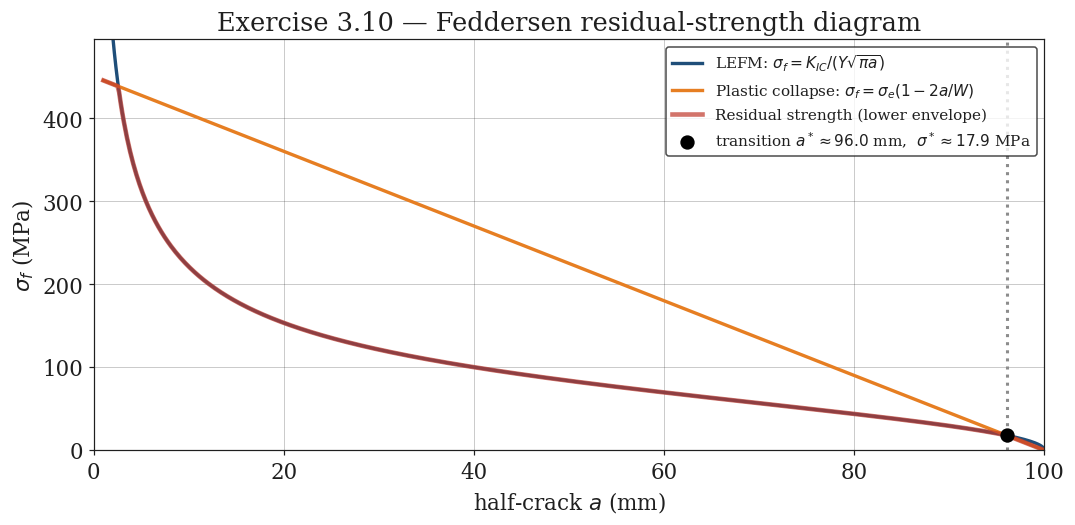

Transition crack length a* ≈ 96.0 mm   (σ* ≈ 17.9 MPa)


In [83]:
W10, K_IC10, sigma_e10 = 200.0, K_IC_Al, 450.0          # mm, MPa√m, MPa

# Range of half-crack lengths
a_arr = np.linspace(1.0, W10/2 - 1e-3, 600)                 # mm
aW    = a_arr/W10
Y     = Y_feddersen(aW)
sigma_LEFM = K_IC10/(Y*np.sqrt(np.pi*a_arr*1e-3))           # MPa
sigma_PL   = sigma_e10*(1 - 2*a_arr/W10)                    # MPa

# Lower envelope of the two
sigma_res = np.minimum(sigma_LEFM, sigma_PL)

# Transition crack: intersection of the two curves
idx_star = np.argmin(np.abs(sigma_LEFM - sigma_PL))
a_star   = a_arr[idx_star]
sig_star = sigma_LEFM[idx_star]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(a_arr, sigma_LEFM, color=COLORS['curve'], lw=2.2, label=r'LEFM: $\sigma_f = K_{IC}/(Y\sqrt{\pi a})$')
ax.plot(a_arr, sigma_PL,   color=COLORS['warn'],  lw=2.2, label=r'Plastic collapse: $\sigma_f=\sigma_e(1-2a/W)$')
ax.plot(a_arr, sigma_res,  color=COLORS['point'], lw=3.0, alpha=0.7,
        label='Residual strength (lower envelope)')
ax.axvline(a_star, color=COLORS['guide'], ls=':')
ax.scatter([a_star], [sig_star], color='black', s=70, zorder=5,
           label=fr'transition $a^*\approx {a_star:.1f}$ mm,  $\sigma^*\approx {sig_star:.1f}$ MPa')
ax.set_xlabel(r'half-crack $a$ (mm)')
ax.set_ylabel(r'$\sigma_f$ (MPa)')
ax.set_xlim(0, W10/2); ax.set_ylim(0, sigma_e10*1.1)
ax.set_title('Exercise 3.10 — Feddersen residual-strength diagram')
ax.legend(loc='upper right', fontsize=10); plt.tight_layout(); plt.show()
print(f'Transition crack length a* ≈ {a_star:.1f} mm   (σ* ≈ {sig_star:.1f} MPa)')


**Engineering significance of $a^{*}$.** For $a<a^{*}$, plastic collapse
controls — failure happens when the net section yields, and the toughness
$K_{IC}$ is **irrelevant**. For $a>a^{*}$, brittle fracture dominates and the
collapse criterion overestimates the strength. The transition crack length is
the boundary between the two regimes; it provides a useful **design check**:
if the largest credible flaw is well below $a^{*}$, the structure is yielding-
limited and the fracture toughness can be relaxed; if it is above $a^{*}$,
$K_{IC}$ governs and damage-tolerance becomes the priority.


<a id='ex11'></a>
---

## Exercise 3.11 — Conceptual questions on $K$ and crack-tip behaviour

Answer the following conceptual questions. Brief but precise answers are
expected.

1.  Is it possible for the geometry correction factor $\beta$ (or $Y$)
    to have a constant value, independent of the crack length? Give an
    example.

2.  The $K$-field predicts an infinite stress at the crack tip
    ($r \to 0$). In practice, a small plastic zone forms instead.

    1.  Is the $K$-field equation valid inside the plastic zone?

    2.  Explain why $K$ can still be a useful parameter, despite the
        existence of a small plastic zone at the crack tip (*small-scale
        yielding* argument).

3.  Why is the crack tip of a through-thickness crack in a *thick* plate
    approximately in plane strain at low stress levels, while the same
    does not hold for a *thin* sheet?

4.  What is the meaning of the *crack driving force*? How does it relate
    to the energy release rate $G$ and the stress intensity factor $K$?

### Solution

**(a) Can $\beta$ (or $Y$) be constant, independent of $a$?**

Yes — there are geometries where the only available length-scale is $a$
itself, so dimensional analysis forces $\beta$ to be a pure number. The
canonical example is the **edge crack in a semi-infinite plate**, where
$\beta = Y = 1.1215$ (Schijve, Eq. 5.11) for *any* crack length.

**(b) The $K$-field inside the plastic zone.**

(i) **No** — the linear-elastic $K$-field $\sigma=K/\sqrt{2\pi r}$ is *not*
valid inside the plastic zone. The actual stresses are bounded by the flow
behaviour of the material.

(ii) **Small-scale yielding (SSY):** if the plastic zone radius $r_p$ is
much smaller than $a$, $(W-a)$, and $B$, then *outside* the plastic zone
the elastic $K$-field still describes the stresses, and $K$ acts as a
**controlling parameter** for what happens inside. Two cracked bodies with
the same $K$ have the same plastic-zone field and therefore behave the same.
This is the cornerstone of LEFM applicability.

**(c) Plane strain vs. plane stress.**

In a **thick** plate, $\varepsilon_z$ is constrained to ≈ 0 by the
surrounding material → **plane strain**. The high triaxiality keeps the
plastic zone small and the apparent toughness *low* (the $K_{IC}$ floor).

In a **thin** sheet, $\sigma_z\to 0$ at the free surfaces → **plane stress**.
Lower triaxiality allows larger plastic zones and **higher** apparent
toughness ($K_c$, depending on thickness). The transition occurs roughly when
the plastic-zone size becomes comparable to the thickness.

**(d) Crack driving force and $G$–$K$ relation.**

The **crack driving force** is the energy released per unit new crack area
as the crack extends:

\begin{equation*}
G = -\dfrac{\partial \Pi}{\partial A},
\tag{3.11.1}\end{equation*}

where $\Pi$ is the potential energy of the loaded body. For Mode I, plane
stress: $G=K^{2}/E$; plane strain: $G=K^{2}(1-\nu^{2})/E$. So $G$ and $K$ are
two equivalent descriptions of the same crack-tip driving force, related by a
material elasticity factor. Griffith's criterion $G=G_c$ is the energy
equivalent of $K=K_{IC}$.


---

### Final remarks

* All numerical results follow from the formulary at the top: $K=Y\sigma\sqrt{\pi a}$,
  the shape functions of CCT/SEN-3PB/CT, the fracture condition $K=K_{IC}$, and
  the plane-strain validity (F.6).
* The residual-strength diagram (Ex 3.10) is the natural bridge between
  ductile yielding ($\sigma_e$) and brittle fracture ($K_{IC}$); $a^{*}$
  determines which mechanism governs.
* Plane-strain $K_{IC}$ values become impossible to measure as ductility grows;
  for those cases the $J$-integral or CTOD are the appropriate parameters
  (covered in advanced fracture mechanics courses).


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.